<a href="https://colab.research.google.com/github/asm59-345/Emotion_Prediction_Model/blob/main/Emotion_Prediction_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset


2. Load Dataset

In [2]:
load_dataset('dair-ai/emotion')

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
emotion_dataset = load_dataset('dair-ai/emotion')
# emotion_dataset['train'] ['text']

train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [4]:
#0.train_label
#0.1. emotion_dataset
#1.emotion_dataset['train'].features
#2.emotion_dataset['train'].features['label']
#3.emotion_dataset['train'].features['label'].names
label_names = emotion_dataset['train'].features['label'].names

In [5]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
for i in train_label:
  print(label_names[i]) # show characters
  print(i) # shows numerical number

Streaming output truncated to the last 5000 lines.
joy
1
anger
3
fear
4
joy
1
sadness
0
joy
1
sadness
0
anger
3
joy
1
sadness
0
sadness
0
fear
4
love
2
sadness
0
joy
1
love
2
joy
1
fear
4
sadness
0
anger
3
joy
1
fear
4
sadness
0
sadness
0
anger
3
anger
3
fear
4
fear
4
love
2
anger
3
joy
1
sadness
0
love
2
joy
1
sadness
0
surprise
5
anger
3
joy
1
joy
1
fear
4
sadness
0
joy
1
love
2
sadness
0
anger
3
joy
1
anger
3
fear
4
sadness
0
anger
3
sadness
0
joy
1
joy
1
sadness
0
fear
4
joy
1
anger
3
fear
4
sadness
0
fear
4
anger
3
joy
1
sadness
0
joy
1
fear
4
joy
1
sadness
0
sadness
0
sadness
0
joy
1
fear
4
sadness
0
fear
4
joy
1
love
2
joy
1
joy
1
joy
1
joy
1
joy
1
joy
1
fear
4
joy
1
joy
1
sadness
0
fear
4
joy
1
sadness
0
sadness
0
joy
1
joy
1
sadness
0
sadness
0
joy
1
joy
1
sadness
0
sadness
0
love
2
joy
1
surprise
5
sadness
0
sadness
0
love
2
sadness
0
love
2
love
2
joy
1
love
2
anger
3
fear
4
joy
1
joy
1
sadness
0
fear
4
fear
4
fear
4
joy
1
joy
1
anger
3
joy
1
joy
1
anger
3
love
2
fear
4
ange

In [7]:
train_label

Column([0, 0, 3, 2, 3])

In [8]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
    }
)
'''
df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': test_label
    }
)'''

"\ndf_test = pd.DataFrame(\n    {\n        'text': test_text,\n        'label': test_label\n    }\n)"

In [9]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [10]:
df_train.isnull().sum()

,0
text,0
label,0


3.EDA Exploratory Data Analysis


<Axes: ylabel='count'>

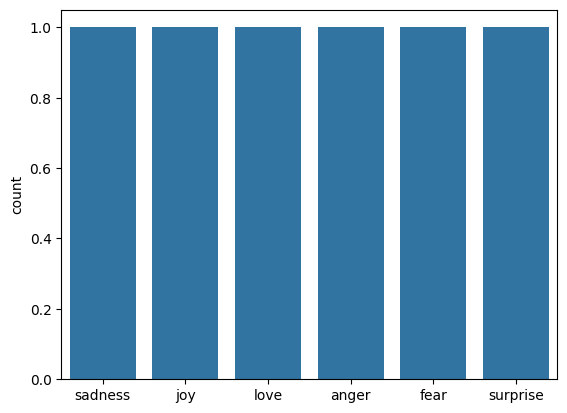

In [11]:
sns.countplot(x = label_names)


<Axes: xlabel='label', ylabel='count'>

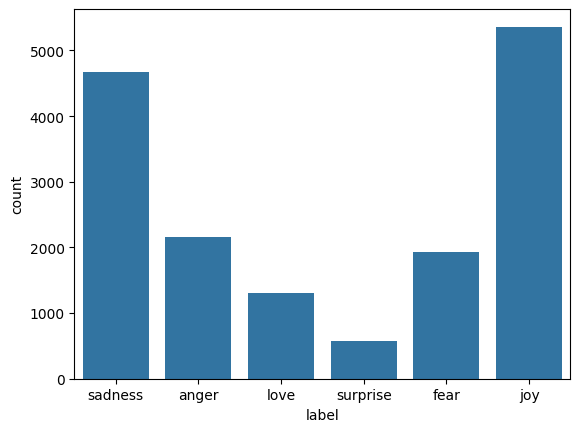

In [12]:
sns.countplot(x = 'label' , data = df_train)

In [13]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

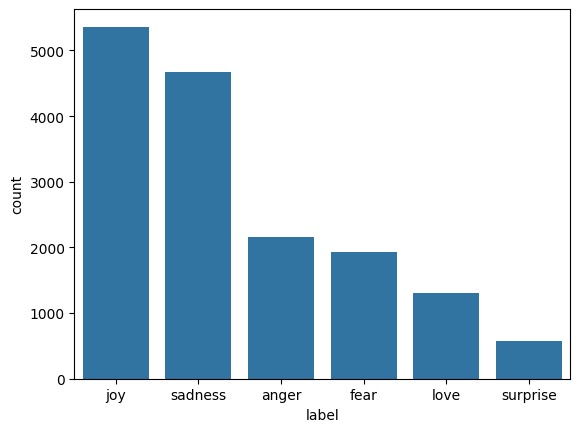

In [14]:
sns.countplot(x='label' , data=df_train, order = df_train['label'].value_counts().index)

4. Data Preprocessing - Using NLP

In [15]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [16]:
df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': test_label
    }
)

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


5. Shared Training Utilities

In [18]:
from sklearn.utils import class_weight
class_weight = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y      =train_labels
)
class_weight_dict = dict(enumerate(class_weight))


In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**6. Phase 1 — Plain Foundational Models**

Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

6.1 Model 1 — Simple RNN

In [20]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),

    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),

    SimpleRNN(units=64),
    Dropout(0.5),

    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.1667 - loss: 1.9225 - val_accuracy: 0.1300 - val_loss: 1.8170
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.1610 - loss: 1.8076 - val_accuracy: 0.1370 - val_loss: 1.7895
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.1555 - loss: 1.7852 - val_accuracy: 0.1435 - val_loss: 1.7751
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.1606 - loss: 1.7771 - val_accuracy: 0.0790 - val_loss: 1.8528
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.1489 - loss: 1.7775 - val_accuracy: 0.1710 - val_loss: 1.7712
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1532 - loss: 1.7672 - val_accuracy: 0.1785 - val_loss: 1.7703
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.1419 - loss: 1.7730 - val_accuracy: 0.1330 - val_loss: 1.7868
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1548 - loss: 1.7411 - val_ac

In [22]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)

print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1785 - loss: 1.7703
RNN Loss: 1.7702707052230835
RNN Accuracy: 0.1784999966621399



6.2 Model 2 — Standard LSTM

In [23]:
lstm_model = Sequential([
    Embedding(input_dim= max_words, output_dim = 128, input_length = 50),
    LSTM(units = 128 , return_sequences = True),
    Dropout(0.5),
    LSTM(units = 64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])
lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)
lstm_loss , lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)

print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.1571 - loss: 1.7948 - val_accuracy: 0.1120 - val_loss: 1.7901
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.1597 - loss: 1.7929 - val_accuracy: 0.0810 - val_loss: 1.7948
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1526 - loss: 1.7858 - val_accuracy: 0.1305 - val_loss: 1.8052
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1120 - loss: 1.7901
LSTM Loss: 1.7901488542556763
LSTM Accuracy: 0.1120000034570694


**6.3 Model 3 — Standard GRU**

In [24]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1579 - loss: 1.7964 - val_accuracy: 0.0360 - val_loss: 1.8008
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1610 - loss: 1.7945 - val_accuracy: 0.1375 - val_loss: 1.7833
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1563 - loss: 1.7938 - val_accuracy: 0.1405 - val_loss: 1.7738
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0360 - loss: 1.8008
GRU Loss: 1.8007726669311523
GRU Accuracy: 0.035999998450279236


**6.4 Phase 1 Ranking & Selection**

In [25]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.770271,0.1785
1,LSTM,1.790149,0.1120
2,GRU,1.800773,0.0360


**7. Phase 2 — Advanced Bidirectional GRU**

7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [26]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
    Bidirectional(GRU(units = 128, return_sequences = True)),
    Dropout(0.5),
    Bidirectional(GRU(units = 64)),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')

])
BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5442 - loss: 1.0900 - val_accuracy: 0.9065 - val_loss: 0.2700
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9219 - loss: 0.2261 - val_accuracy: 0.9200 - val_loss: 0.2466
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9467 - loss: 0.1429 - val_accuracy: 0.9100 - val_loss: 0.2732
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9597 - loss: 0.1098 - val_accuracy: 0.9230 - val_loss: 0.2430
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9721 - loss: 0.0769 - val_accuracy: 0.9140 - val_loss: 0.2677
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9772 - loss: 0.0626 - val_accuracy: 0.9245 - val_loss: 0.2631
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9825 - loss: 0.0525 - val_accuracy: 0.9250 - val_loss: 0.2746


In [28]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9230 - loss: 0.2430
BiGRU Loss: 0.24299770593643188
BiGRU Accuracy: 0.9229999780654907


**8. Overall Evaluation & Bias Analysis**

8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


<Axes: >

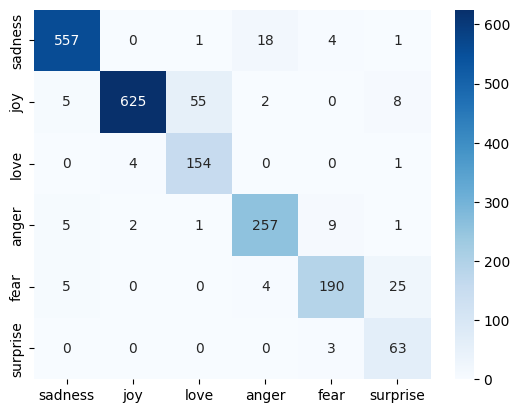

In [31]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)


**9. Final Predictions**

In [32]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise



**10. Save Model & Tokenizer**

In [34]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)